# 07_pseudotime_compare

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline

In [3]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scanpy as sc
from pathlib import Path

In [322]:
combined_fn = "results/07/pseudotime_momac_all.tsv"
combined_df = pd.read_csv(combined_fn, sep="\t", index_col=0, header=[0, 1])

In [323]:
combined_df.columns = pd.MultiIndex.from_tuples([(c.replace('full_smooth', 'smooth_full'), cs) for c, cs in combined_df.columns])

In [325]:
gene_set_counts_df = pd.read_csv("results/07/gene_set_sizes.tsv", sep="\t", index_col=0)
gene_set_counts_df.index = [c.replace('full_smooth', 'smooth_full') for c in gene_set_counts_df.index]

In [326]:
gene_set_counts_df

,n_genes_raw,n_genes_in_adata
momac,17,17
momac_smooth,19,19
momac_hvg,1001,1001
momac_zman_s3,1120,1117
momac_full,50,50
momac_smooth_full,57,57
scumi_hvg_ctet,22,22
scumi_hvg_smooth_ctet,22,22
scumi_full_ctet,50,50
scumi_smooth_full_ctet,57,57


In [327]:
from scipy.stats import spearmanr, pearsonr

In [328]:
methods = ['scorpius', 'dpt', 'redpath', 'monocle2', 'palantir']
gene_sets = ['_zman_s3', '_hvg', '_full', '_smooth_full']
rename_gene_sets = ['zman_s3', 'hvg', 'full', 'smooth_full']

# zman_s3, hvg, 
# naive (spearman on hvg only using raw cTET), 
# smooth (spearman on hvg only using smoothed cTET), 
# full - spearman on full set using raw cTET, smooth_full (spearman on full set using smoothed cTET)

def get_corr_df(combined_df, put_time_col='cTET', version='momac'):
    """
    version: 'momac' or 'scumi' or 'mcumi'. momac and scumi should be similar.
    """

    method_gene_set_corr_df = pd.DataFrame(index=pd.MultiIndex.from_product([methods, gene_sets]), columns=["correlation", "pval"])
    method_gene_set_corr_df.index.names = ["method", "gene_set"]
    for method in methods:
        for gene_set in gene_sets:
            ctet_str = "_ctet" if version in ['mcumi', 'scumi'] and gene_set != '_zman_s3' else ""
            col_name = f"{method}_{version}{gene_set}{ctet_str}"

            gene_set_full = f"{version}{gene_set}{ctet_str}"

            meta_version = f"meta_{version}" if version in ['mcumi', 'scumi'] else "meta"
            
            pearson_corr, pval = pearsonr(combined_df[(meta_version, put_time_col)], combined_df[(col_name, 'pseudotime')])
            method_gene_set_corr_df.loc[(method, gene_set), 'correlation'] = pearson_corr
            method_gene_set_corr_df.loc[(method, gene_set), 'pval'] = pval
            method_gene_set_corr_df.loc[(method, gene_set), 'gene_set_full'] = gene_set_full

            
    method_gene_set_corr_df = method_gene_set_corr_df.reset_index()
    method_gene_set_corr_df['gene_set'] = method_gene_set_corr_df['gene_set'].replace('', '_naive')
    method_gene_set_corr_df['gene_set'] = method_gene_set_corr_df['gene_set'].apply(lambda x: x.strip('_'))
    method_gene_set_corr_df['gene_set'] = pd.Categorical(method_gene_set_corr_df['gene_set'], categories=rename_gene_sets, ordered=True)
    return method_gene_set_corr_df

In [329]:
raw_corr_df = get_corr_df(combined_df, put_time_col='cTET', version='momac')
smooth_corr_df = get_corr_df(combined_df, put_time_col='smooth_cTET', version='momac')

scumi_raw_corr_df = get_corr_df(combined_df, put_time_col='cTET', version='scumi')
scumi_smooth_corr_df = get_corr_df(combined_df, put_time_col='smooth_cTET', version='scumi')

mcumi_raw_corr_df = get_corr_df(combined_df, put_time_col='cTET', version='mcumi')
mcumi_smooth_corr_df = get_corr_df(combined_df, put_time_col='smooth_cTET', version='mcumi')


In [330]:
scumi_raw_corr_df

,method,gene_set,correlation,pval,gene_set_full
0,scorpius,zman_s3,0.46088,0.000453,scumi_zman_s3
1,scorpius,hvg,0.565151,0.000008,scumi_hvg_ctet
2,scorpius,full,0.666371,0.0,scumi_full_ctet
3,scorpius,smooth_full,0.6575,0.0,scumi_smooth_full_ctet
4,dpt,zman_s3,0.526132,0.000044,scumi_zman_s3
5,dpt,hvg,0.463085,0.000422,scumi_hvg_ctet
6,dpt,full,0.744272,0.0,scumi_full_ctet
7,dpt,smooth_full,0.576708,0.000005,scumi_smooth_full_ctet
8,redpath,zman_s3,0.656407,0.0,scumi_zman_s3
9,redpath,hvg,0.643856,0.0,scumi_hvg_ctet


In [307]:
%matplotlib inline

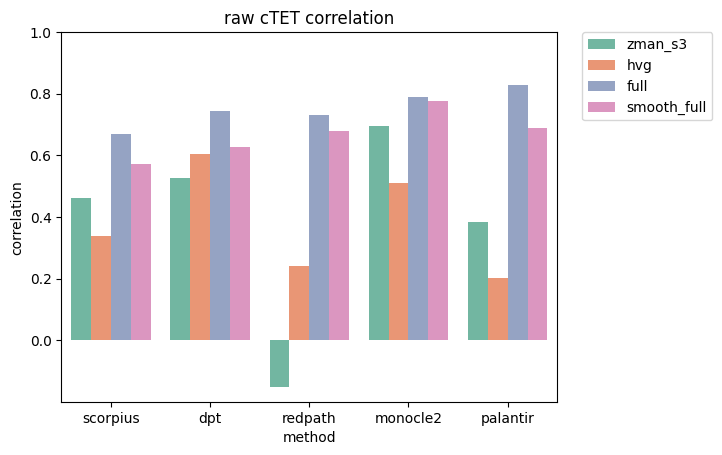

In [331]:
sns.barplot(data=raw_corr_df, x="method", y="correlation", hue="gene_set", legend=True, palette="Set2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("raw cTET correlation")
plt.ylim(None, 1)
plt.show()

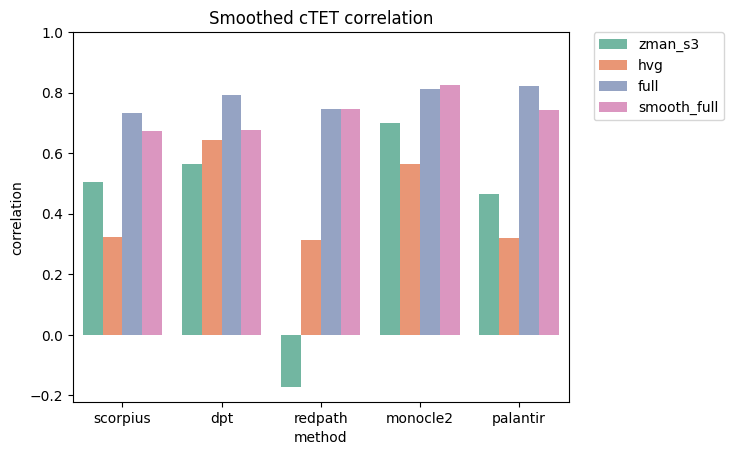

In [332]:
sns.barplot(data=smooth_corr_df, x="method", y="correlation", hue="gene_set", legend=True, palette="Set2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("Smoothed cTET correlation")
plt.ylim(None, 1)
plt.show()

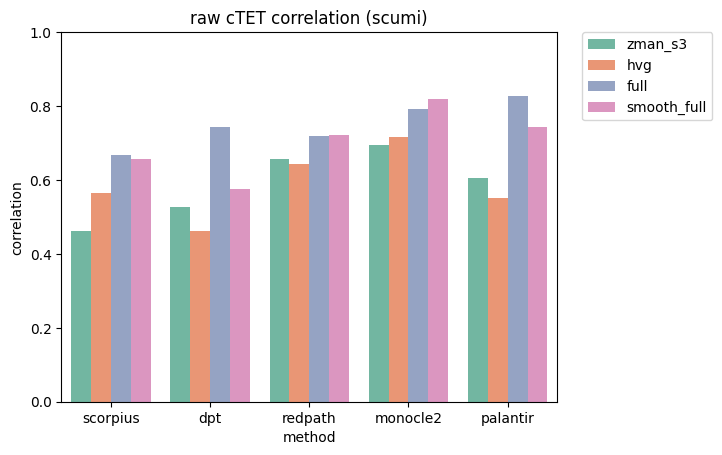

In [333]:
sns.barplot(data=scumi_raw_corr_df, x="method", y="correlation", hue="gene_set", legend=True, palette="Set2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("raw cTET correlation (scumi)")
plt.ylim(0, 1)
plt.show()

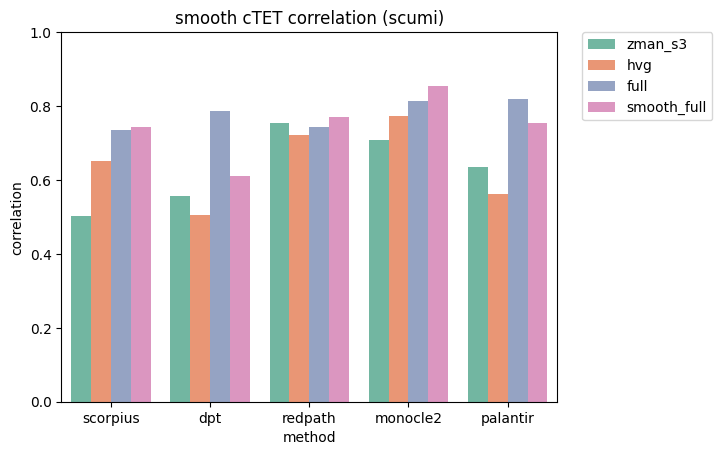

In [334]:
sns.barplot(data=scumi_smooth_corr_df, x="method", y="correlation", hue="gene_set", legend=True, palette="Set2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("smooth cTET correlation (scumi)")
plt.ylim(0, 1)
plt.show()

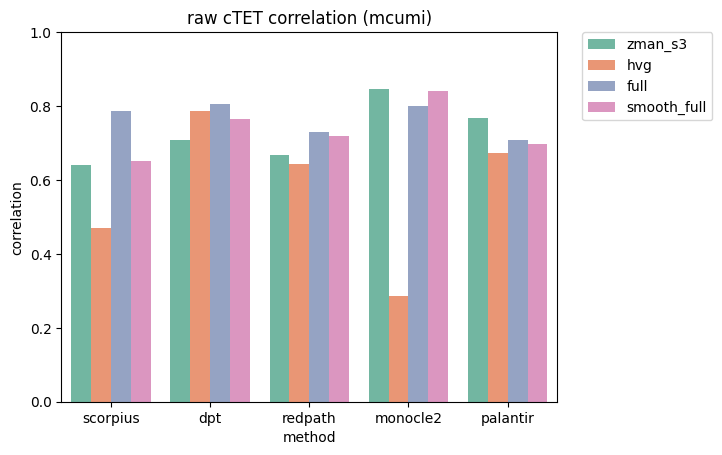

In [335]:
sns.barplot(data=mcumi_raw_corr_df, x="method", y="correlation", hue="gene_set", legend=True, palette="Set2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("raw cTET correlation (mcumi)")
plt.ylim(0, 1)
plt.show()

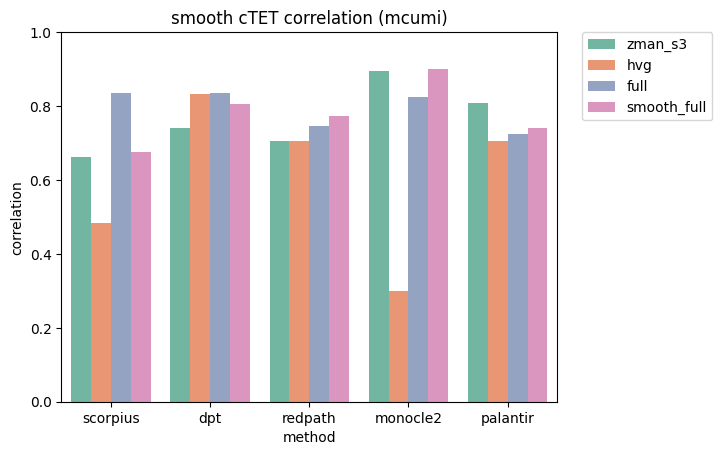

In [350]:
sns.barplot(data=mcumi_smooth_corr_df, x="method", y="correlation", hue="gene_set", legend=True, palette="Set2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("smooth cTET correlation (mcumi)")
plt.ylim(0, 1)
plt.show()

In [337]:
combined_df[('meta', 'metacell_cell_type')].unique()

array(['Arg1_TAM', 'Acp5_TAM', 'MoMac1', 'MoMac2', 'Monocytes',
       'Gpnmb_TAM'], dtype=object)

In [338]:
cell_type_colors = {
    'Arg1_TAM': 'tab:blue', 'Acp5_TAM': 'tab:purple', 'MoMac1': 'orange', 'MoMac2': 'green', 'Monocytes': 'yellow',
       'Gpnmb_TAM': 'red'
}

In [339]:
myeloid_cell_type_colors = {
    'Arg1_TAM': "mediumorchid", 
    'Acp5_TAM': "slateblue", 
    'MoMac1': "tab:blue", 
    'MoMac2': "tab:red", 
    'Monocytes': "tab:orange", 
    'cDC2': "goldenrod", 
    'MonDC': "gold", 
    'Gpnmb_TAM': "lightblue", 
    'cDC1': "darkkhaki", 
    'MigDC': "tab:brown",
    'transitory': "teal",
    "pDC": "tab:green",
}


In [340]:
gene_set_counts_df

,n_genes_raw,n_genes_in_adata
momac,17,17
momac_smooth,19,19
momac_hvg,1001,1001
momac_zman_s3,1120,1117
momac_full,50,50
momac_smooth_full,57,57
scumi_hvg_ctet,22,22
scumi_hvg_smooth_ctet,22,22
scumi_full_ctet,50,50
scumi_smooth_full_ctet,57,57


In [344]:
def plot_pseudotime_scatter(combined_df, methods, gene_sets, coor_df, ctet_col='cTET', version='momac', rug_height=.05):
    """
    version: 'momac' or 'scumi' or 'mcumi'. momac and scumi should be similar.
    """

    fig, axes = plt.subplots(len(gene_sets), len(methods), figsize=(15, 10), sharex=True)

    for (method, gene_set), r in coor_df.iterrows():
        ctet_str = "_ctet" if version in ['mcumi', 'scumi'] and gene_set != 'zman_s3' else ""
        i = gene_sets.index(gene_set)
        j = methods.index(method)
        last = i == 0 and j == len(methods) - 1
        meta_version = f"meta_{version}" if version in ['mcumi', 'scumi'] else "meta"

        sns.scatterplot(
            x=combined_df[(meta_version, ctet_col)], 
            y=combined_df[(f"{method}_{r['gene_set_full']}", 'pseudotime')], 
            hue=combined_df[("meta", 'metacell_cell_type')], # keep as shared meta table
            palette=cell_type_colors, s=50, edgecolor='black', linewidth=0.5,
            ax=axes[i, j], legend=False if not last else True
        )
        # rug plot
        sns.rugplot(
            x=combined_df[(meta_version, ctet_col)], 
            y=combined_df[(f"{method}_{r['gene_set_full']}", 'pseudotime')], 
            hue=combined_df[("meta", 'metacell_cell_type')],
            palette=cell_type_colors, height=rug_height, linewidth=1, alpha=0.8,
            ax=axes[i, j], legend=False
        )
        axes[i, j].set_title(f"{method} (r={r['correlation']:.2f})")
        axes[i, j].set_ylabel(f'{gene_set.strip("_")} (n={gene_set_counts_df.loc[f"{version}_{gene_set}{ctet_str}", "n_genes_in_adata"]})')
        axes[i, j].set_xlabel(f'{ctet_col}')
        
        

        if last:
            axes[i, j].legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
        
    plt.tight_layout()
    return fig, axes

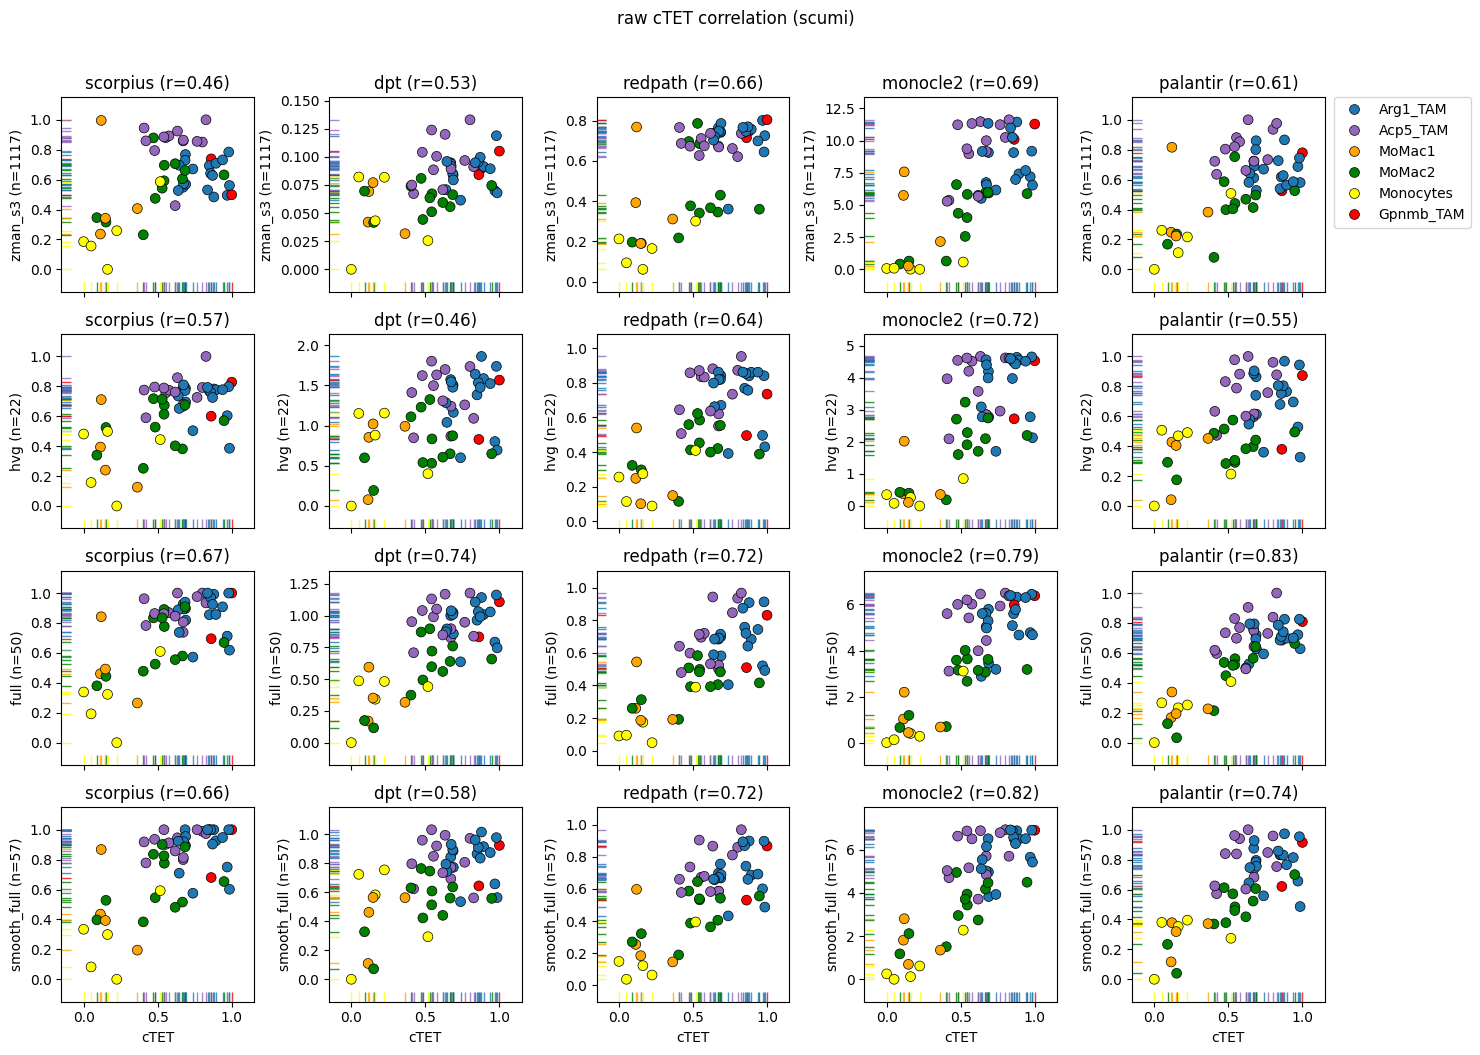

In [346]:
fig, axes = plot_pseudotime_scatter(
    combined_df, methods, rename_gene_sets, scumi_raw_corr_df.set_index(['method', 'gene_set']), 
    ctet_col='cTET', version='scumi'
)
plt.suptitle("raw cTET correlation (scumi)", y=1.05)
plt.show()

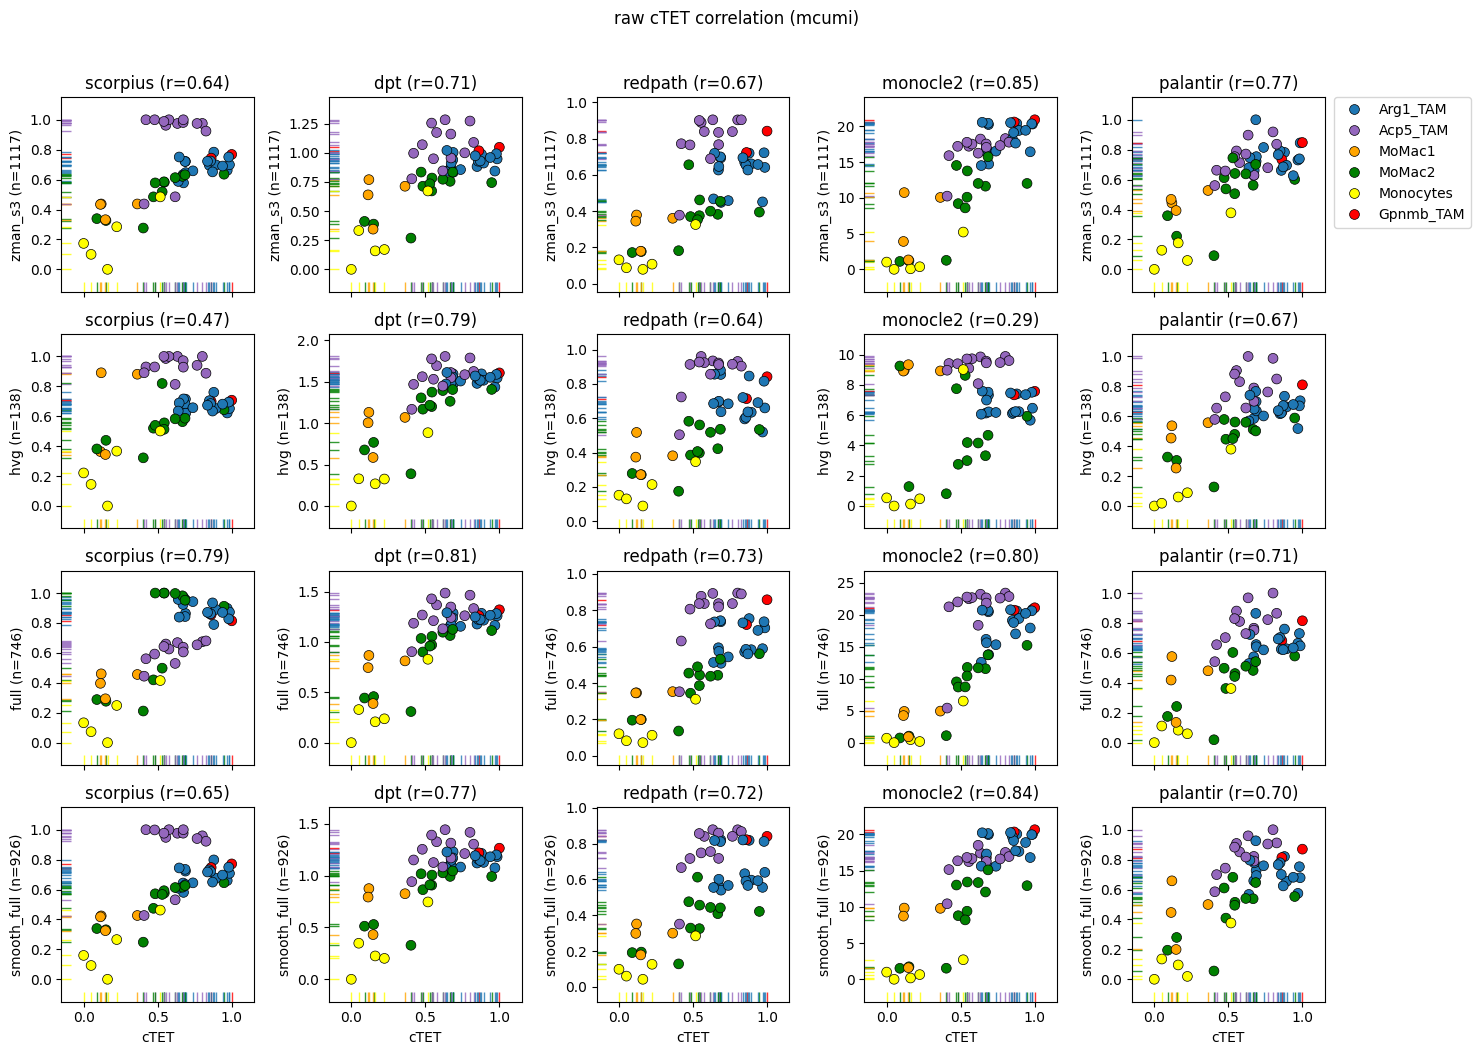

In [347]:
fig, axes = plot_pseudotime_scatter(
    combined_df, methods, rename_gene_sets, mcumi_raw_corr_df.set_index(['method', 'gene_set']), 
    ctet_col='cTET', version='mcumi'
)
plt.suptitle("raw cTET correlation (mcumi)", y=1.05)
plt.show()

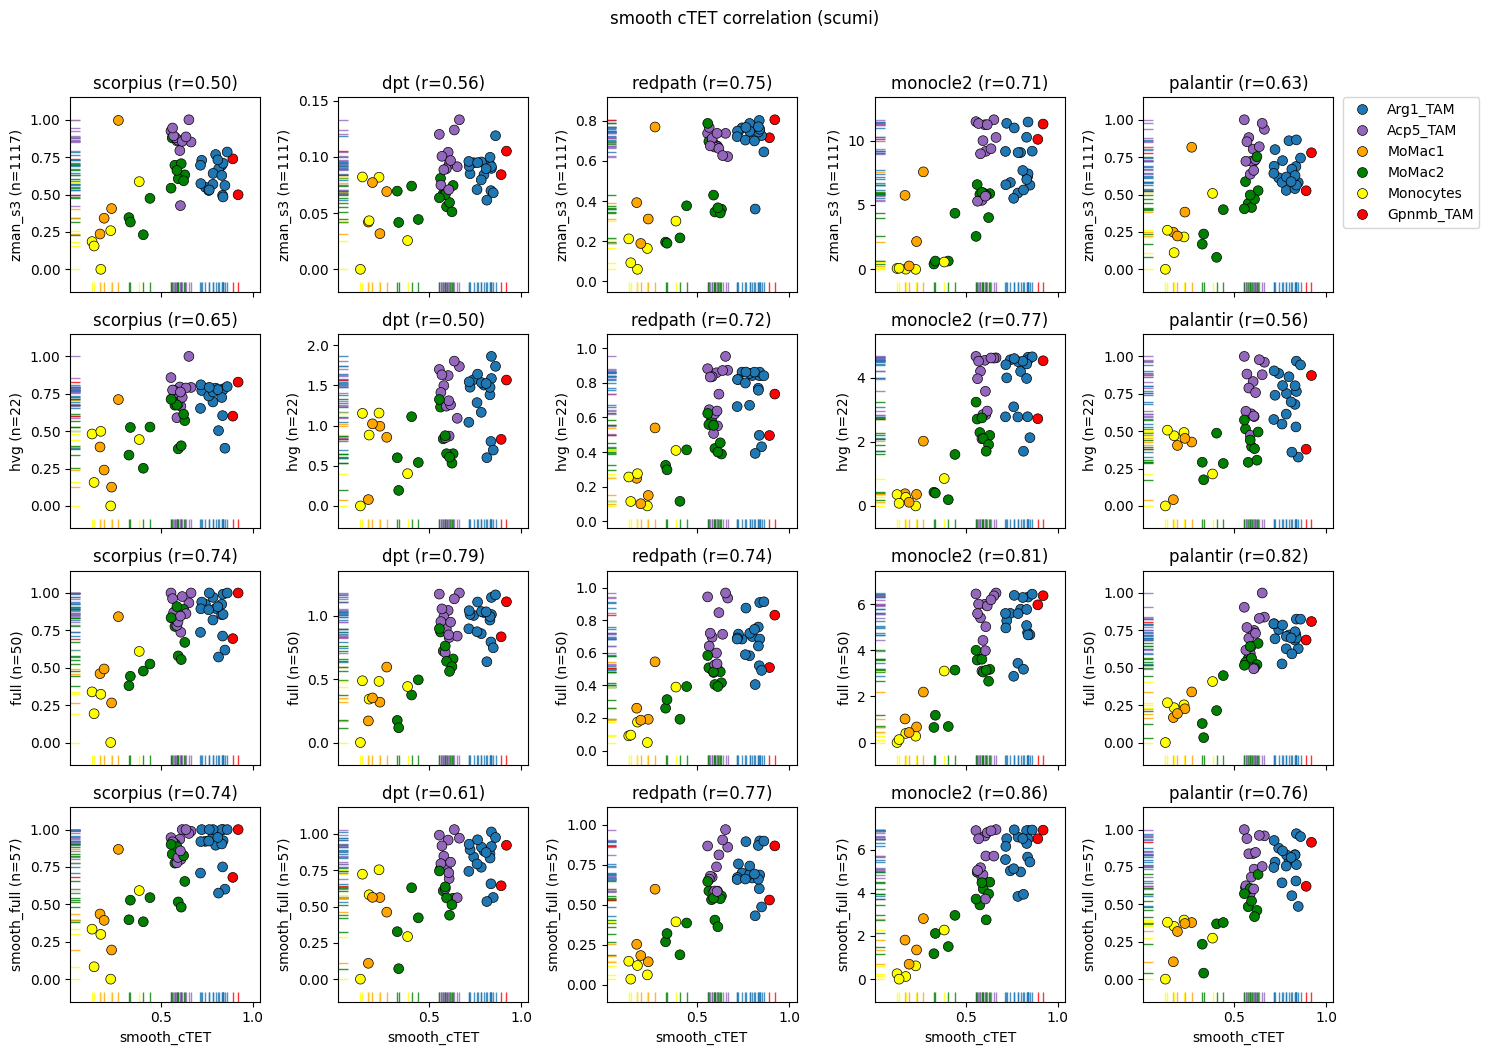

In [348]:
fig, axes = plot_pseudotime_scatter(
    combined_df, methods, rename_gene_sets, scumi_smooth_corr_df.set_index(['method', 'gene_set']), 
    ctet_col='smooth_cTET', version='scumi'
)
plt.suptitle("smooth cTET correlation (scumi)", y=1.05)
plt.show()

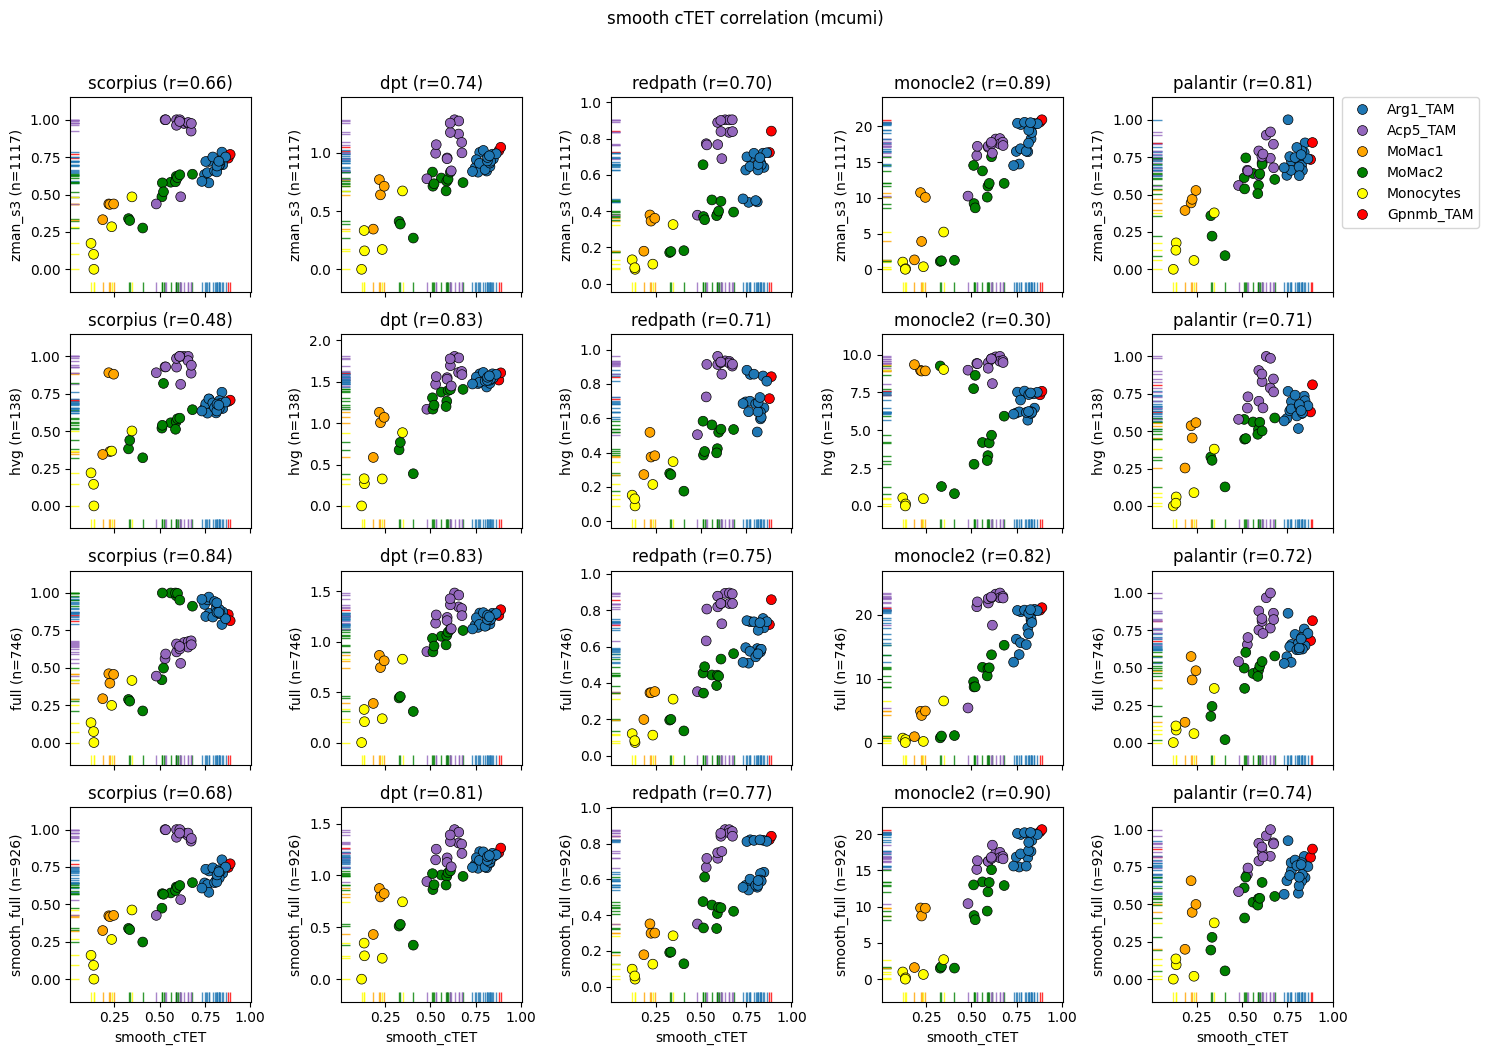

In [349]:
fig, axes = plot_pseudotime_scatter(
    combined_df, methods, rename_gene_sets, mcumi_smooth_corr_df.set_index(['method', 'gene_set']), 
    ctet_col='smooth_cTET', version='mcumi'
)
plt.suptitle("smooth cTET correlation (mcumi)", y=1.05)
plt.show()

Monocle2 can produce pseudotimes larger than 1. This is because this represents an actual distance in the manifold

Todo: set the root to a monocyte for all of them